# Multimodal XAI Framework for Real Estate Valuation
---
## Feature Fusion & Model Comparison
##


## Setting Up

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
import lightgbm as lgb
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

BASE       = '/content/drive/MyDrive/SRED_thesis'
META_DIR   = f'{BASE}/metadata'
EMB_DIR    = f'{BASE}/embeddings'
OUTPUT_DIR = f'{BASE}/results'

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Ready.")

Mounted at /content/drive
Ready.


In [ ]:
#Load Data
train = pd.read_csv(f'{META_DIR}/train_processed.csv')
test  = pd.read_csv(f'{META_DIR}/test_processed.csv')

train['listing_id'] = train['listing_id'].astype(int)
test['listing_id']  = test['listing_id'].astype(int)

TABULAR_FEATURES = ['living_space', 'rooms', 'lat', 'lon']
TARGET           = 'log_price'

print(f"Train: {len(train):,} | Test: {len(test):,}")
print(f"Tabular features: {TABULAR_FEATURES}")

Train: 9,996 | Test: 1,109
Tabular features: ['living_space', 'rooms', 'lat', 'lon']


##Image Embeddings

In [ ]:
# Load embeddings and align with tabular data
# Must be aligned  with the tabular dataframe by listing_id

train_pca      = np.load(f'{EMB_DIR}/train_embeddings_pca128.npy')
test_pca       = np.load(f'{EMB_DIR}/test_embeddings_pca128.npy')
train_valid_ids = pd.read_csv(f'{EMB_DIR}/train_valid_ids.csv').iloc[:,0].astype(int).tolist()
test_valid_ids  = pd.read_csv(f'{EMB_DIR}/test_valid_ids.csv').iloc[:,0].astype(int).tolist()

# Build embedding dataframes with listing_id as index
pca_cols = [f'pca_{i}' for i in range(128)]

train_emb_df = pd.DataFrame(train_pca, columns=pca_cols)
train_emb_df['listing_id'] = train_valid_ids

test_emb_df = pd.DataFrame(test_pca, columns=pca_cols)
test_emb_df['listing_id'] = test_valid_ids

# Merge tabular + embeddings on listing_id
train_full = train.merge(train_emb_df, on='listing_id', how='inner')
test_full  = test.merge(test_emb_df,  on='listing_id', how='inner')

print(f"Train after merge: {len(train_full):,} (dropped {len(train)-len(train_full)} unmatched)")
print(f"Test after merge:  {len(test_full):,} (dropped {len(test)-len(test_full)} unmatched)")

Train after merge: 9,996 (dropped 0 unmatched)
Test after merge:  1,109 (dropped 0 unmatched)


In [ ]:
# Feature Configurations
TABULAR_ONLY  = TABULAR_FEATURES
IMAGE_ONLY    = pca_cols
MULTIMODAL    = TABULAR_FEATURES + pca_cols

print(f"Tabular-only:  {len(TABULAR_ONLY)} features")
print(f"Image-only:    {len(IMAGE_ONLY)} features")
print(f"Multimodal:    {len(MULTIMODAL)} features")

Tabular-only:  4 features
Image-only:    128 features
Multimodal:    132 features


In [ ]:
# Evaluation Metrics
# All metrics computed on original price scale (CHF), not log scale.

def compute_metrics(y_true_log, y_pred_log, label=''):
    # Converting back to CHF for interpretable metrics
    y_true = np.exp(y_true_log)
    y_pred = np.exp(y_pred_log)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    if label:
        print(f"\n{label}")
        print(f"  RMSE: CHF {rmse:,.0f}")
        print(f"  MAE:  CHF {mae:,.0f}")
        print(f"  R²:   {r2:.4f}")
        print(f"  MAPE: {mape:.2f}%")

    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

In [ ]:
# LightGBM parameters
# These parameters are grounded in literature: Ke et al. (2017) recommend histogram-based splitting for high-dimensional data.
# num_leaves and learning_rate follow standard practice for tabular regression.

LGBM_PARAMS = {
    'objective':        'regression',
    'metric':           'rmse',
    'num_leaves':       64,
    'learning_rate':    0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq':     5,
    'min_child_samples': 20,
    'reg_alpha':        0.1,
    'reg_lambda':       0.1,
    'verbose':          -1,
    'random_state':     42
}

XGBM_PARAMS = {
    'objective':        'reg:squarederror',
    'eval_metric':      'rmse',
    'max_depth':        6,
    'learning_rate':    0.05,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'reg_alpha':        0.1,
    'reg_lambda':       0.1,
    'n_estimators':     1000,
    'random_state':     42,
    'verbosity':        0
}

print("Parameters defined.")

Parameters defined.


In [ ]:
# Training function with early stopping
def train_lgbm(X_train, y_train, X_test, y_test, params, label):
    dtrain = lgb.Dataset(X_train, label=y_train)
    dval   = lgb.Dataset(X_test,  label=y_test, reference=dtrain)

    callbacks = [
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=-1)
    ]

    model = lgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        valid_sets=[dval],
        callbacks=callbacks
    )

    y_pred = model.predict(X_test)
    metrics = compute_metrics(y_test, y_pred, label=label)
    print(f"  Best iteration: {model.best_iteration}")
    return model, y_pred, metrics


def train_xgbm(X_train, y_train, X_test, y_test, params, label):
    model = xgb.XGBRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    y_pred = model.predict(X_test)
    metrics = compute_metrics(y_test, y_pred, label=label)
    return model, y_pred, metrics

In [ ]:
# Preparing feature arrays
X_train_tab  = train_full[TABULAR_ONLY].values
X_train_img  = train_full[IMAGE_ONLY].values
X_train_mm   = train_full[MULTIMODAL].values
y_train      = train_full[TARGET].values

X_test_tab   = test_full[TABULAR_ONLY].values
X_test_img   = test_full[IMAGE_ONLY].values
X_test_mm    = test_full[MULTIMODAL].values
y_test       = test_full[TARGET].values

print(f"Train shapes — tabular: {X_train_tab.shape} | image: {X_train_img.shape} | multimodal: {X_train_mm.shape}")
print(f"Test shapes  — tabular: {X_test_tab.shape}  | image: {X_test_img.shape}  | multimodal: {X_test_mm.shape}")

Train shapes — tabular: (9996, 4) | image: (9996, 128) | multimodal: (9996, 132)
Test shapes  — tabular: (1109, 4)  | image: (1109, 128)  | multimodal: (1109, 132)



#Training Models
---

Four models are trained across three feature configurations:
- **Model 1** (LightGBM, tabular-only): baseline with tabular features alone
- **Model 2** (LightGBM, image-only): visual features alone
- **Model 3** (LightGBM, multimodal): proposed framework
- **Model 4** (XGBoost, multimodal): algorithm comparison against the same feature set

In [ ]:
# Training 4 Models
print("=" * 55)
print("TRAINING ALL MODELS")
print("=" * 55)

# Model 1: LightGBM tabular-only (baseline)
m1, pred_m1, met_m1 = train_lgbm(
    X_train_tab, y_train, X_test_tab, y_test,
    LGBM_PARAMS, "Model 1: LightGBM — Tabular only (baseline)"
)

# Model 2: LightGBM image-only
m2, pred_m2, met_m2 = train_lgbm(
    X_train_img, y_train, X_test_img, y_test,
    LGBM_PARAMS, "Model 2: LightGBM — Image only"
)

# Model 3: LightGBM multimodal (proposed framework)
m3, pred_m3, met_m3 = train_lgbm(
    X_train_mm, y_train, X_test_mm, y_test,
    LGBM_PARAMS, "Model 3: LightGBM — Multimodal (proposed framework)"
)

# Model 4: XGBoost multimodal (comparison)
m4, pred_m4, met_m4 = train_xgbm(
    X_train_mm, y_train, X_test_mm, y_test,
    XGBM_PARAMS, "Model 4: XGBoost — Multimodal (comparison)"
)

TRAINING ALL MODELS

Model 1: LightGBM — Tabular only (baseline)
  RMSE: CHF 267
  MAE:  CHF 182
  R²:   0.7740
  MAPE: 10.43%
  Best iteration: 433

Model 2: LightGBM — Image only
  RMSE: CHF 514
  MAE:  CHF 347
  R²:   0.1600
  MAPE: 20.46%
  Best iteration: 144

Model 3: LightGBM — Multimodal (proposed framework)
  RMSE: CHF 290
  MAE:  CHF 182
  R²:   0.7324
  MAPE: 10.22%
  Best iteration: 326

Model 4: XGBoost — Multimodal (comparison)
  RMSE: CHF 294
  MAE:  CHF 188
  R²:   0.7246
  MAPE: 10.58%


In [ ]:
# Results comparison table

results = pd.DataFrame({
    'Model': [
        'LightGBM — Tabular only',
        'LightGBM — Image only',
        'LightGBM — Multimodal',
        'XGBoost  — Multimodal'
    ],
    'Features': [
        '4 tabular',
        '128 PCA (image)',
        '4 tabular + 128 PCA',
        '4 tabular + 128 PCA'
    ],
    'RMSE (CHF)': [met_m1['RMSE'], met_m2['RMSE'], met_m3['RMSE'], met_m4['RMSE']],
    'MAE (CHF)':  [met_m1['MAE'],  met_m2['MAE'],  met_m3['MAE'],  met_m4['MAE']],
    'R²':         [met_m1['R2'],   met_m2['R2'],   met_m3['R2'],   met_m4['R2']],
    'MAPE (%)':   [met_m1['MAPE'], met_m2['MAPE'], met_m3['MAPE'], met_m4['MAPE']]
})

results['RMSE (CHF)'] = results['RMSE (CHF)'].round(0).astype(int)
results['MAE (CHF)']  = results['MAE (CHF)'].round(0).astype(int)
results['R²']         = results['R²'].round(4)
results['MAPE (%)']   = results['MAPE (%)'].round(2)

print("\n=== MODEL COMPARISON — TEST SET RESULTS ===")
print(results.to_string(index=False))

results.to_csv(f'{OUTPUT_DIR}/model_comparison.csv', index=False)
print("\nSaved to results/model_comparison.csv")


=== MODEL COMPARISON — TEST SET RESULTS ===
                  Model            Features  RMSE (CHF)  MAE (CHF)     R²  MAPE (%)
LightGBM — Tabular only           4 tabular         267        182 0.7740     10.43
  LightGBM — Image only     128 PCA (image)         514        347 0.1600     20.46
  LightGBM — Multimodal 4 tabular + 128 PCA         290        182 0.7324     10.22
  XGBoost  — Multimodal 4 tabular + 128 PCA         294        188 0.7246     10.58

Saved to results/model_comparison.csv


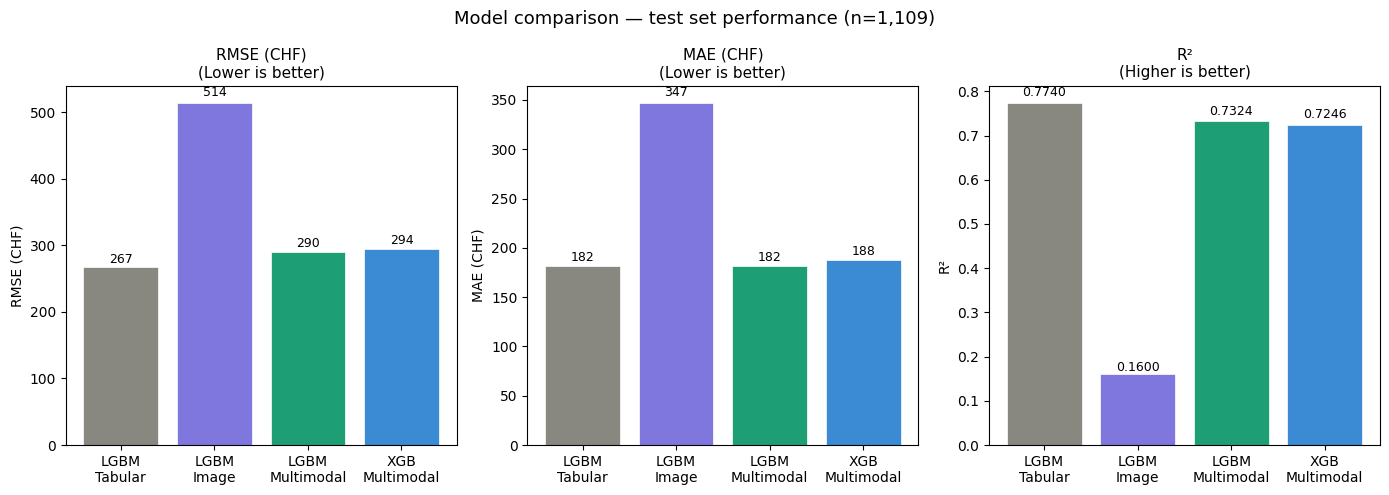

Figure 5 saved.


In [ ]:
# Results bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

model_labels = ['LGBM\nTabular', 'LGBM\nImage', 'LGBM\nMultimodal', 'XGB\nMultimodal']
colors = ['#888780', '#7F77DD', '#1D9E75', '#3B8BD4']

metrics_to_plot = [
    ('RMSE (CHF)', 'RMSE (CHF)', 'Lower is better'),
    ('MAE (CHF)',  'MAE (CHF)',  'Lower is better'),
    ('R²',        'R²',         'Higher is better'),
]

for ax, (col, ylabel, note) in zip(axes, metrics_to_plot):
    vals = results[col].values
    bars = ax.bar(model_labels, vals, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(f'{ylabel}\n({note})', fontsize=11)
    ax.set_ylabel(ylabel)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01,
                f'{val:,.0f}' if 'CHF' in ylabel else f'{val:.4f}',
                ha='center', va='bottom', fontsize=9)

plt.suptitle('Model comparison — test set performance (n=1,109)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig5_model_comparison.png', bbox_inches='tight')
plt.show()
print("Figure 5 saved.")

In [ ]:
#Saving
import joblib

joblib.dump(m1, f'{OUTPUT_DIR}/model_lgbm_tabular.pkl')
joblib.dump(m2, f'{OUTPUT_DIR}/model_lgbm_image.pkl')
joblib.dump(m3, f'{OUTPUT_DIR}/model_lgbm_multimodal.pkl')
joblib.dump(m4, f'{OUTPUT_DIR}/model_xgbm_multimodal.pkl')

# Save test predictions for later analysis
np.save(f'{OUTPUT_DIR}/pred_m1.npy', pred_m1)
np.save(f'{OUTPUT_DIR}/pred_m3.npy', pred_m3)

# Save aligned test dataframe — needed for Notebooks 4 and 5
test_full.to_csv(f'{OUTPUT_DIR}/test_full_aligned.csv', index=False)
train_full.to_csv(f'{OUTPUT_DIR}/train_full_aligned.csv', index=False)

print("All models and predictions saved.")
print("Notebook 3 complete.")

All models and predictions saved.
Notebook 3 complete.
